# 04 — Menggali World Happiness Report

Apa yang membuat sebuah negara "bahagia"? Pada Latihan ini saya akan mencoba menganalisis **World Happiness Report 2019** untuk memahami faktor-faktor yang berhubungan dengan skor kebahagiaan negara, seperti ekonomi, dukungan sosial, dan kebebasan.

> 🎯 **Tujuan Pembelajaran**
> - Mengurutkan & menyaring data untuk menemukan negara ter-bahagia/ter-tidak bahagia.
> - Menghitung **korelasi** antar variabel.
> - Membaca **heatmap korelasi** untuk melihat faktor paling berpengaruh.
> - Membuat scatter plot untuk menyelidiki hubungan dua variabel.

## 📊 Tentang Dataset

Dataset ini memuat skor kebahagiaan **156 negara** beserta faktor penyumbangnya, dari laporan
PBB (UN Sustainable Development Solutions Network) tahun 2019.

- **Sumber:** [Kaggle — unsdsn/world-happiness](https://www.kaggle.com/datasets/unsdsn/world-happiness)
- **File:** `2019.csv` — 156 baris × 9 kolom

| Kolom | Arti |
|-------|------|
| `Overall rank` | Peringkat kebahagiaan |
| `Country or region` | Nama negara |
| `Score` | Skor kebahagiaan (semakin tinggi semakin bahagia) |
| `GDP per capita` | Kontribusi ekonomi per kapita |
| `Social support` | Dukungan sosial |
| `Healthy life expectancy` | Harapan hidup sehat |
| `Freedom to make life choices` | Kebebasan menentukan pilihan |
| `Generosity` | Kedermawanan |
| `Perceptions of corruption` | Persepsi korupsi (kepercayaan thd pemerintah) |

## 1. Import Library

- **pandas** → olah tabel.
- **numpy** → angka.
- **matplotlib**/**seaborn** → grafik.
- `load_kaggle_dataset` → memuat data nyata (di-cache).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Instal Kaggle
!pip install -q kaggle

# Pastikan file kaggle.json sudah di-upload ke Colab
# Jalankan perintah ini untuk mendownload dan unzip otomatis
# file 2019

!kaggle datasets download unsdsn/world-happiness

Dataset URL: https://www.kaggle.com/datasets/unsdsn/world-happiness
License(s): CC0-1.0
100% 36.8k/36.8k [00:00<00:00, 31.5MB/s]



In [3]:
import zipfile

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

zip_file_path = '/content/world-happiness.zip'
csv_file_in_zip = '2019.csv'

with zipfile.ZipFile(zip_file_path, 'r') as zf:
    with zf.open(csv_file_in_zip) as f:
        df = pd.read_csv(f)

df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


Interpretasi :

Berdasarkan Overall Rank. ini lah 5 negara teratas dengan kebahagian tertinggi didunia diantara lainnya, menurut file laporan tahun 2019.

## Eksplorasi Awal

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [5]:
df.isnull().sum()

,0
Overall rank,0
Country or region,0
Score,0
GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0


Interpretasi :     
terdapat 9 kolom dengan 156 baris atau negara yang terindeks dalam survey tingkat kebahagiaan. dari masing masing data tidak terdapat nilai yang hilang

In [6]:
df.describe()

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


**Interpretasi `describe()`:** Skor kebahagiaan berkisar dari ~2.85 (terendah) hingga ~7.77 (tertinggi), dengan rata-rata sekitar 5.4. Faktor `GDP per capita` dan `Social support` punya nilai rata-rata cukup tinggi dibanding `Generosity` dan `Perceptions of corruption`.

## Negara Ter-bahagia & Ter-tidak Bahagia

Mari urutkan untuk menemukan 10 negara teratas dan terbawah.

In [7]:
#TOP 10
top_10 = df.sort_values(by='Score', ascending=False).head(10)

print("10 Negara Ter-Bahagia:")
print(top_10[['Country or region', 'Score']])


10 Negara Ter-Bahagia:
  Country or region  Score
0           Finland  7.769
1           Denmark  7.600
2            Norway  7.554
3           Iceland  7.494
4       Netherlands  7.488
5       Switzerland  7.480
6            Sweden  7.343
7       New Zealand  7.307
8            Canada  7.278
9           Austria  7.246


In [8]:
#Bottom 10
bottom_10 = df.sort_values(by='Score').head(10)

print("10 Negara Ter-Tidak Bahagia:")
print(bottom_10[['Country or region', 'Score']])

10 Negara Ter-Tidak Bahagia:
            Country or region  Score
155               South Sudan  2.853
154  Central African Republic  3.083
153               Afghanistan  3.203
152                  Tanzania  3.231
151                    Rwanda  3.334
150                     Yemen  3.380
149                    Malawi  3.410
148                     Syria  3.462
147                  Botswana  3.488
146                     Haiti  3.597


Interpretasi :    
- negara negara dibenua eropa mendominasi tingkat kebahagian, kecuali NZ dan Canada
- negara negara dibenua afrika mendominasi tingkat ketidak bahagiaan penduduk, Kecuali Yaman dan Afganistan

## EDA & Visualisasi


a ) 10 Negara paling bahagia ( barchart )

/tmp/ipykernel_12886/3553260306.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='Country or region', data=top_10, palette='viridis')


Text(0, 0.5, 'Skor Kebahagiaan')

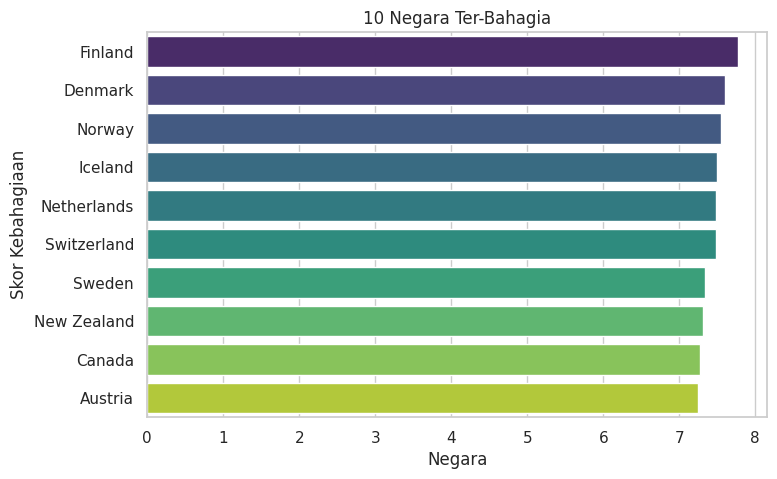

In [10]:
sns.barplot(x='Score', y='Country or region', data=top_10, palette='viridis')
plt.title('10 Negara Ter-Bahagia')
plt.xlabel('Negara')
plt.ylabel('Skor Kebahagiaan')

Interpretasi :     
Inilah 10 negara dengan penduduk paling bahagia, didukung dengan ekonomi yang kuat, dukungan sosial yang tinggi dan sistem pemerintahan yang baik, dengan rentang score diangka 7.6 - 7.9

b ) 10 Negara paling tidak bahagia ( barchart )

/tmp/ipykernel_12886/1895305539.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='Country or region', data=bottom_10, palette='viridis')


Text(0, 0.5, 'Skor Kebahagiaan')

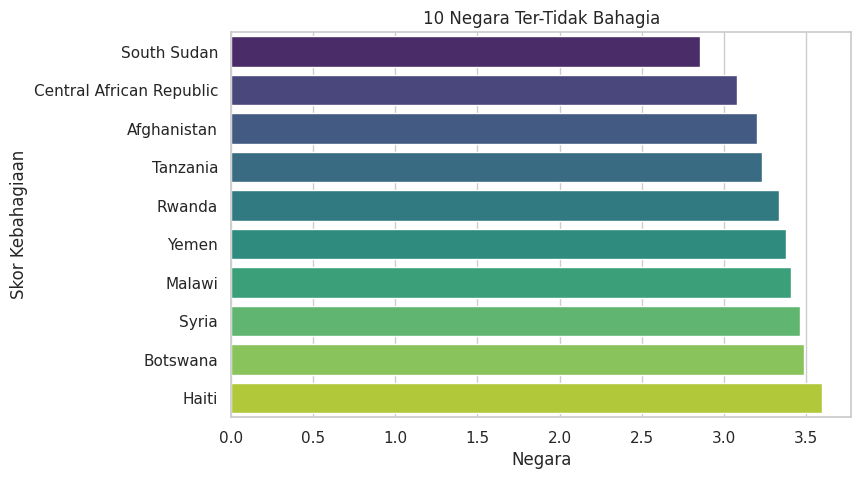

In [15]:
sns.barplot(x='Score', y='Country or region', data=bottom_10, palette='viridis')
plt.title('10 Negara Ter-Tidak Bahagia')
plt.xlabel('Negara')
plt.ylabel('Skor Kebahagiaan')

Interpretasi :     
Inilah 10 negara dengan penduduk paling tidak bahagia, selain faktor ekonomi, faktor ketidak percayaan terhadap pemerintah mempengaruhi score kebahagiaan masyarakat direntang angka 2.8 - 3.6

### c) Heatmap korelasi antar faktor

heatmap menunjukkan seberapa kuat hubungan antar variable, jika score heatmap = 1, korelasi sempurna, jika score heatmap = -1, negatif sempurna)

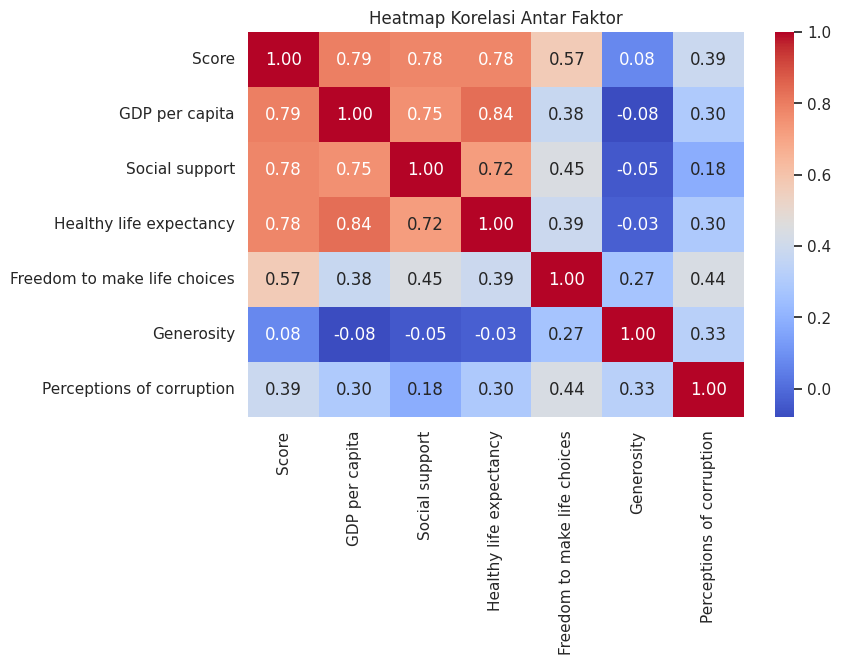

In [16]:
#heatmap

x = df.drop(['Overall rank', 'Country or region'], axis=1) #buang variable kategori dan urutan rank
corr_matrix = x.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Antar Faktor')
plt.show()

Interpretasi :    
Berdasarkan Heatmap, Tinggi rendahnya nilai Score Happiness sebuah negara, bisa dipengaruhi oleh beberapa faktor utama, seperti :              
- GDP per Capita
- Social Support
- Healthy Life Expectancy


Sementara Tingkat kedermawanan tidak berpengaruh terhadap Score Happiness

yang berati tingkat kebahagian suatu negara bisa ditentukan oleh Ekonomi, Dukungan Sosial yang Tinggi, dan Kesehatan atau harapan hidup warga negara itu sendiri

### d) Hubungan GDP per kapita vs skor kebahagiaan (scatter)

Text(0, 0.5, 'Skor Kebahagiaan')

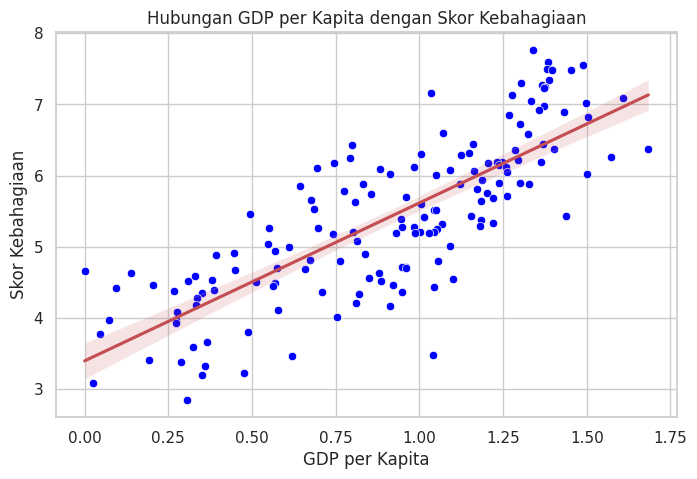

In [21]:
#GDP per Capita vs Score
sns.scatterplot(x='GDP per capita', y='Score', data=df, color='blue')
sns.regplot(x='GDP per capita', y='Score', data=df, scatter=False, color='red')
plt.title('Hubungan GDP per Kapita dengan Skor Kebahagiaan')
plt.xlabel('GDP per Kapita')
plt.ylabel('Skor Kebahagiaan')

Tren terlihat naik

Semakin Tinggi GDP per Kapita, Cenderung semakin tinggi skor kebahagian, tapi uang bukanlah satu satunya faktor yang menentukan tingkat kebahagian

### e) Hubungan Social Support vs skor kebahagiaan (scatter)

Text(0, 0.5, 'Skor Kebahagiaan')

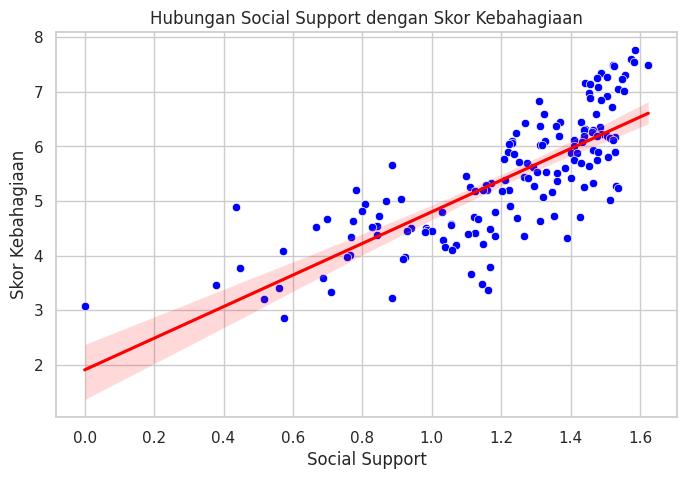

In [22]:
#Social Support vs Score
sns.scatterplot(x='Social support', y='Score', data=df, color='blue')
sns.regplot(x='Social support', y='Score', data=df, scatter=False, color='red')
plt.title('Hubungan Social Support dengan Skor Kebahagiaan')
plt.xlabel('Social Support')
plt.ylabel('Skor Kebahagiaan')

Terlihat trend naik

Menunjukkan bahwa semakin tinggi tingkat dukungan sosial, semakin tinggi tingkat score kebahagiaan

### f) Hubungan Healthy Life Expectancy vs skor kebahagiaan (scatter)

Text(0, 0.5, 'Skor Kebahagiaan')

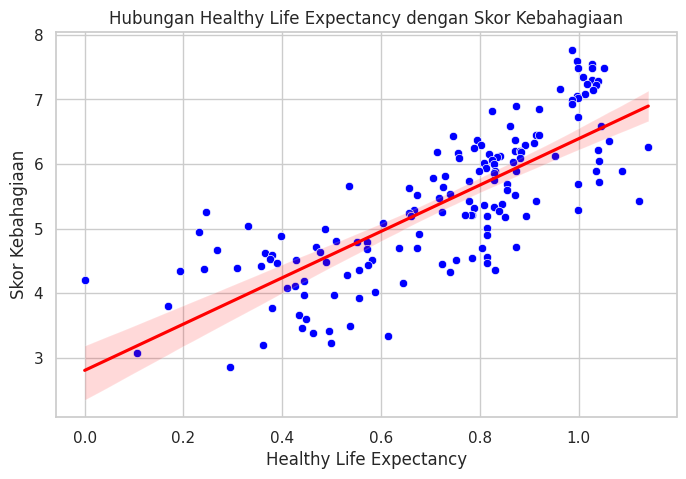

In [23]:
#HLE vs Score
sns.scatterplot(x='Healthy life expectancy', y='Score', data=df, color='blue')
sns.regplot(x='Healthy life expectancy', y='Score', data=df, scatter=False, color='red')
plt.title('Hubungan Healthy Life Expectancy dengan Skor Kebahagiaan')
plt.xlabel('Healthy Life Expectancy')
plt.ylabel('Skor Kebahagiaan')

Healthy Life Expectancy dengan trend Naik

Menunjukkan semakin tinggi HLE, cenderung semakin tinggi tingkat skor kebahagiaan

### g) Distribusi skor kebahagiaan (histogram)

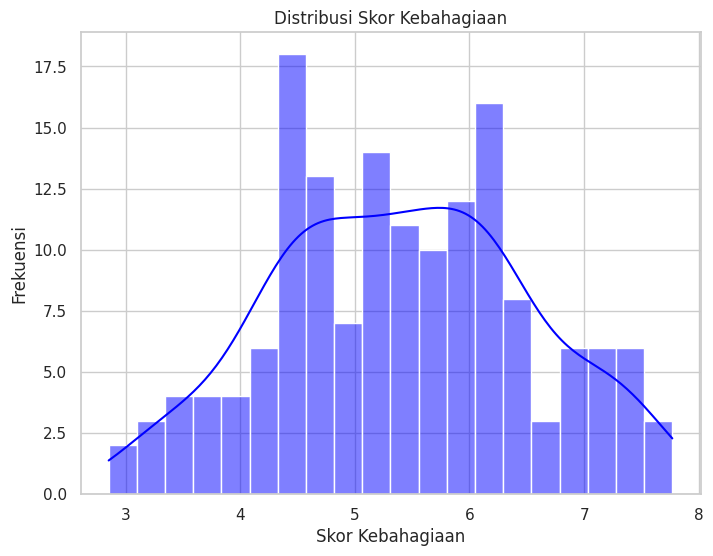

In [25]:
#histogram Score
plt.figure(figsize=(8, 6))
sns.histplot(df['Score'], bins=20, kde=True, color='blue')
plt.title('Distribusi Skor Kebahagiaan')
plt.xlabel('Skor Kebahagiaan')
plt.ylabel('Frekuensi')
plt.show()

Interpretasi


Terlihat dari Kurva seperti distribusi normal. dengan artian sebagian besar score kebahagiaan suatu Negara berkumpul di skor tengah 4.4 - 6.5, Hanya sebagian kecil negara yang memiliki tingkat kebahagian tinggi dan rendah

### h) Posisi Indonesia didalam Score Happiness Report

In [26]:
# Indonesia Position
df_indonesia = df[df['Country or region'] == 'Indonesia']
print(df_indonesia)

    Overall rank Country or region  Score  GDP per capita  Social support  \
91            92         Indonesia  5.192           0.931           1.203   

    Healthy life expectancy  Freedom to make life choices  Generosity  \
91                     0.66                         0.491       0.498   

    Perceptions of corruption  
91                      0.028  


In [27]:
#posisi indonesia vs mean
indonesia_score = df_indonesia['Score'].values[0]
mean_score = df['Score'].mean()

print(f"Skor kebahagiaan Indonesia: {indonesia_score}")
print(f"Skor kebahagiaan rata-rata: {mean_score}")

Skor kebahagiaan Indonesia: 5.192
Skor kebahagiaan rata-rata: 5.407096153846155


Indonesia berada di urutan 91 dari 165 negara. jika di lihat dari rata rata score, posisi indonesia masih dibawah rata rata tingkat kebahagian negara negara didunia

## Kesimpulan & Insight

- Negara **Nordik** mendominasi puncak kebahagiaan dunia 2019.
- Faktor paling berkorelasi dengan kebahagiaan: **GDP per kapita, dukungan sosial, harapan hidup sehat**.
- **Kedermawanan (Generosity)** hampir tidak berkorelasi dengan skor.
- Sebagian besar negara berada di skor menengah (distribusi mendekati normal).
- Insight kebijakan: meningkatkan ekonomi, jaring pengaman sosial, dan kesehatan berpotensi
  paling besar menaikkan kesejahteraan warga.

## 💼 Rekomendasi & Insight Bisnis

Bagi pembuat kebijakan, dua pengungkit kebahagiaan terkuat adalah **GDP per kapita** dan **dukungan sosial** — keduanya hampir sama kuat. Artinya pertumbuhan ekonomi *dan* jaring pengaman sosial (kesehatan, komunitas) sama-sama layak diinvestasikan untuk menaikkan kesejahteraan warga.

### ⚠️ Jebakan Data
**Korelasi bukan sebab-akibat.** Negara yang kaya cenderung lebih bahagia, tetapi data ini tidak membuktikan bahwa menaikkan GDP *menyebabkan* kebahagiaan — bisa jadi ada faktor lain (budaya, pemerintahan) yang memengaruhi keduanya. Hati-hati menyimpulkan "X menyebabkan Y" hanya dari korelasi.